Kmeans

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from datetime import datetime
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import mean_shift, estimate_bandwidth
from sklearn.metrics import silhouette_score


ModuleNotFoundError: No module named 'eda'

In [2]:
costumer_basket = pd.read_csv("customer_basket.csv")
costumer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


In [1]:
dispersion = []

for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(costumer_preprocessed)
    dispersion.append(kmeans.inertia_) 

NameError: name 'KMeans' is not defined

In [ ]:
plt.plot(range(1, 50), dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion')
plt.title('Elbow Method')
plt.show()

NameError: name 'costumer_preprocessed' is not defined

ValueError: x and y must have same first dimension, but have shapes (9,) and (0,)

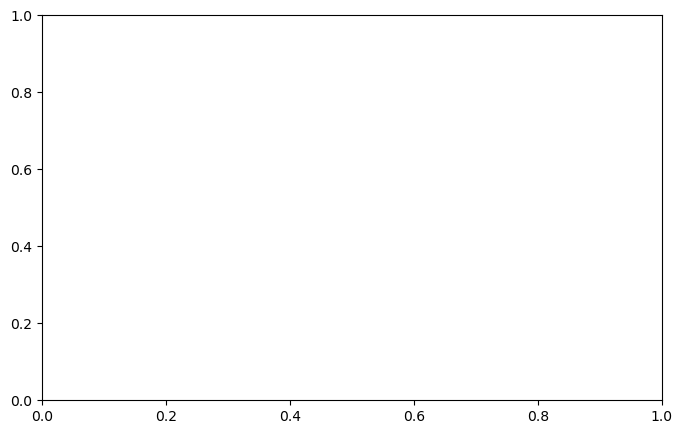

In [ ]:
elbow1 = 6
elbow2 = 19

plt.plot(range(1, 50), dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion')
plt.title('Elbow Method – candidate K values')
plt.vlines(elbow1, min(dispersion), max(dispersion), color='red', label=f'k={elbow1}')
plt.vlines(elbow2, min(dispersion), max(dispersion), color='red', label=f'k={elbow2}')
plt.legend()
plt.show()

In [ ]:
chosen_k = 6

kmeans = KMeans(n_clusters=chosen_k, random_state=0).fit(costumer_preprocessed)

# Attach cluster labels back to the original (unscaled) dataframe
# so the group means are interpretable in real units
costumer['cluster_kmeans'] = kmeans.predict(costumer_preprocessed)

In [ ]:
profile_cols = costumer.drop(columns=['customer_id', 'customer_name'], errors='ignore')

print("── Cluster means ──")
print(profile_cols.groupby('cluster_kmeans').mean().T)  # .T makes it easier to read

print("\n── Overall means ──")
print(profile_cols.mean())

In [ ]:
profile_cols.groupby('cluster_kmeans').size().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of customers')
plt.title(f'Cluster sizes (k={chosen_k})')
plt.tight_layout()
plt.show()